<a href="https://colab.research.google.com/github/GhoshSrabonti/Apex-University-Network/blob/main/Lab1_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Lab: Data Preprocessing in Python
**Duration:** 2 Hours &nbsp;|&nbsp; **Level:** Undergraduate &nbsp;|&nbsp; **Tools:** Python · pandas · numpy · matplotlib

---

## Learning Objectives
By the end of this lab you will be able to:
1. Identify and handle missing values using multiple strategies
2. Detect and smooth noisy data using binning
3. Apply min-max, z-score, and decimal-scaling normalisation
4. Perform basic discretisation using equal-width and equal-frequency binning

---

## Schedule

| Time | Section |
|------|---------|
| 0:00 – 0:15 | Setup & Dataset Exploration |
| 0:15 – 0:55 | **Part 1:** Data Quality & Cleaning |
| 1:05 – 1:45 | **Part 2:** Normalisation & Transformation |
| 1:45 – 2:00 | Wrap-up & Reflection |

---

## Dataset Columns

| Column | Type | Description |
|--------|------|-------------|
| `customer_id` | Integer | Unique customer identifier |
| `age` | Numeric | Customer age (years) |
| `income` | Numeric | Annual income (USD) |
| `years_as_customer` | Numeric | How long they've been a customer |
| `num_complaints` | Numeric | Number of complaints filed |
| `units_sold` | Numeric | Units purchased in last period |
| `price` | Numeric | Average item price paid |
| `region` | Nominal | Geographic region (North/South/East/West) |
| `credit_risk` | Nominal | Credit risk label (Low/Medium/High) |

> 💡 **Legend:** Cells marked **`# TODO`** are yours to complete. Cells with full code are demos — run them and study the output.


## ⚙️ Setup — Run this cell first

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")


✅ Libraries imported successfully
   pandas  2.2.3
   numpy   2.1.3


---
## 📥 Load the Dataset

The dataset is hosted on Google Drive and is ready to load — just **run the cell below**, no changes needed.

> 💡 The data will be fetched directly from a shared Google Drive link.


In [ ]:
# ── Dataset pre-filled by instructor — just run this cell ────────────────
FILE_ID = "1os13RmjjjFrjJaSqtIh7eZPlpFw90ulE"
# ─────────────────────────────────────────────────────────────────────────

url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"
df  = pd.read_csv(url)

print("✅ Dataset loaded:", df.shape[0], "rows,", df.shape[1], "columns")
df.head()

✅ Dataset loaded: 200 rows, 9 columns


,customer_id,age,income,years_as_customer,num_complaints,units_sold,price,region,credit_risk
0,1,56.0,56032.20,11.0,0.0,43.0,94.56,South,Low
1,2,69.0,34008.90,4.0,0.0,1.0,66.72,North,Low
2,3,46.0,NaN,4.0,3.0,36.0,62.73,East,High
3,4,32.0,51546.62,NaN,0.0,26.0,53.71,East,Medium
4,5,60.0,39488.20,5.0,0.0,29.0,26.91,West,Medium


---
## Part 1 — Data Quality & Cleaning

### Step 1 · Explore & Profile the Data (10 min)


**[DEMO]** Run and read — understand the shape, dtypes, and null counts.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        200 non-null    int64  
 1   age                190 non-null    float64
 2   income             180 non-null    float64
 3   years_as_customer  195 non-null    float64
 4   num_complaints     192 non-null    float64
 5   units_sold         200 non-null    float64
 6   price              200 non-null    float64
 7   region             200 non-null    object 
 8   credit_risk        200 non-null    object 
dtypes: float64(6), int64(1), object(2)
memory usage: 14.2+ KB


In [ ]:
df.describe().round(2)


,customer_id,age,income,years_as_customer,num_complaints,units_sold,price
count,200.00,190.00,180.00,195.00,192.00,200.00,200.00
mean,100.50,43.18,56073.64,9.99,1.28,31.42,53.01
std,57.88,15.08,37265.83,5.57,3.67,70.17,28.50
min,1.00,18.00,7928.69,0.10,0.00,1.00,0.01
25%,50.75,31.00,42171.28,5.00,0.00,15.00,26.72
50%,100.50,43.00,53701.09,10.00,1.00,26.00,55.10
75%,150.25,56.00,66005.49,15.00,2.00,39.00,78.20
max,200.00,69.00,500000.00,19.00,50.00,999.00,99.73


**[TODO 1]** Complete the cell below to compute the number and percentage of missing values
for **every** column, then display the result as a DataFrame.


In [ ]:
# TODO 1 ── Missing value audit ─────────────────────────────────────────
# Hint: use df.isnull().sum() for counts, then divide by len(df) * 100 for %

# missing = ___________________        # count of nulls per column
# pct     = ___________________        # percentage of nulls per column
missing= df.isnull().sum()
pct = (df.isnull().sum() / len(df)) * 100

# Build and display a summary DataFrame
summary = pd.DataFrame({"Missing": missing, "% Missing": pct})
# display only columns that actually have missing values
summary[summary["Missing"] > 0]




,Missing,% Missing
customer_id,0,0.0
age,10,5.0
income,20,10.0
years_as_customer,5,2.5
num_complaints,8,4.0
units_sold,0,0.0
price,0,0.0
region,0,0.0
credit_risk,0,0.0


**[DEMO]** Income distribution — notice anything unusual?

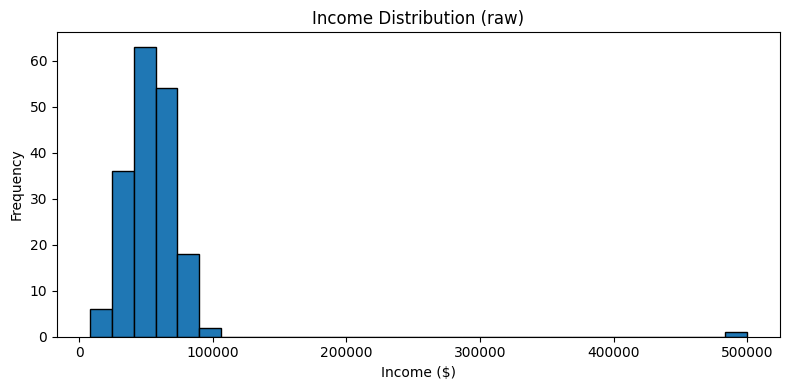

Mean   : $56,074
Median : $53,701
Max    : $500,000


In [ ]:
df['income'].plot(kind='hist', bins=30, edgecolor='black', figsize=(8, 4),
                  title='Income Distribution (raw)')
plt.xlabel('Income ($)')
plt.tight_layout()
plt.show()

print(f"Mean   : ${df['income'].mean():,.0f}")
print(f"Median : ${df['income'].median():,.0f}")
print(f"Max    : ${df['income'].max():,.0f}")


**[TODO 2]** Print the mean, median, and max for **`num_complaints`** and **`years_as_customer`**.  
Do you notice any suspicious values?


In [ ]:
for col in ['num_complaints', 'years_as_customer']:
    print(f"--- {col} ---")
    # print(f"  Mean   : {_______________}")
    # print(f"  Median : {_______________}")
    # print(f"  Max    : {_______________}")
    # print()

print(f"Mean   : ${df[col].mean()})
print(f"Median : ${df[col].median()})
print(f"Max    : ${df[col].max()})
print()


--- num_complaints ---
  Mean   : 1.28125
  Median : 1.0
  Max    : 50.0

--- years_as_customer ---
  Mean   : 9.99025641025641
  Median : 10.0
  Max    : 19.0



### ✏️ Questions — Step 1

1. Which columns have missing values, and what percentage is missing in each?
2. Compare the **mean** and **median** of `income`. Is the distribution symmetric or skewed?
3. What suspicious values did you find in `num_complaints` or `years_as_customer`?

> **Write your answers here (double-click to edit):**
>
> 1.
> 2.
> 3.


---
### Step 2 · Handling Missing Values (15 min)

We compare **three strategies** for filling missing values across the numeric columns.


**[DEMO]** Strategy 1: drop rows that have *any* missing value.

In [ ]:
df_drop = df.dropna().copy()
print(f"Rows before drop: {len(df)}")
print(f"Rows after  drop: {len(df_drop)}")
print(f"Rows lost       : {len(df) - len(df_drop)}")


Rows before drop: 200
Rows after  drop: 159
Rows lost       : 41


**[DEMO]** Strategy 2: fill `income` with the **global mean**.

In [ ]:
df_mean = df.copy()
global_mean = df_mean['income'].mean()
df_mean['income'] = df_mean['income'].fillna(global_mean)
print(f"Global mean used: ${global_mean:,.0f}")
print(f"Missing after fill: {df_mean['income'].isnull().sum()}")


**[DEMO]** Strategy 3: fill `income` with the **class-based mean** (grouped by `credit_risk`).

In [ ]:
df_class = df.copy()
df_class['income'] = (
    df_class.groupby('credit_risk')['income']
            .transform(lambda x: x.fillna(x.mean()))
)
print("Mean income per credit_risk group (used for imputation):")
print(df_class.groupby('credit_risk')['income'].mean().round(0))
print(f"\nMissing income after fill: {df_class['income'].isnull().sum()}")


Mean income per credit_risk group (used for imputation):
credit_risk
High      61763.0
Low       52471.0
Medium    54013.0
Name: income, dtype: float64

Missing income after fill: 0


**[TODO 3]** Apply **Strategy 3 (class-based mean)** to fill missing values in  
`num_complaints` and `years_as_customer` — grouped by `credit_risk`, just like we did for `income`.


In [ ]:
# TODO 3 ── Class-based mean fill for new columns ────────────────────────
for col in ['num_complaints', 'years_as_customer']:
    df_class[col] = (
        df_class.groupby('credit_risk')[col]
                .transform(lambda x:x.fillna(x.mean())) # fill NaNs with group mean
    )
    print(f"{col} — missing after fill: {df_class[col].isnull().sum()}")

num_complaints — missing after fill: 0
years_as_customer — missing after fill: 0


**[DEMO]** Compare the three income distributions side-by-side.

NameError: name 'df_mean' is not defined

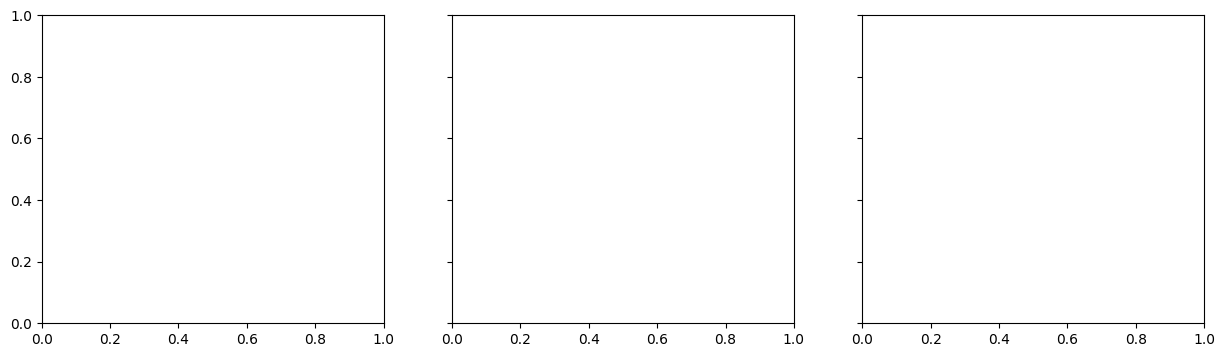

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, data, title in zip(
        axes,
        [df_drop['income'], df_mean['income'], df_class['income']],
        ['Strategy 1: Drop', 'Strategy 2: Global Mean', 'Strategy 3: Class Mean']):
    ax.hist(data, bins=25, edgecolor='black')
    ax.set_title(title); ax.set_xlabel('Income ($)'); ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()


**[TODO 4]** The column `region` is **nominal** — it cannot be filled with a mean.  
Print the value counts of `region` to understand its distribution, then decide:  
should we drop rows with a missing `region`, or fill with the **mode**?  
Implement your chosen strategy on `df_class`.

*(Note: the dataset may or may not have missing `region` values — the audit in TODO 1 will tell you.)*


In [ ]:
# TODO 4 ── Handle nominal column 'region' ───────────────────────────────
print("Region value counts:")
print(df_class['region'].value_counts())
print(f"Missing: {df_class['region'].isnull().sum()}")

# If there are missing values, fill with the mode:
# df_class['region'] = df_class['region'].fillna(___________________)


Region value counts:
region
North    56
East     52
South    47
West     45
Name: count, dtype: int64
Missing: 0


### ✏️ Questions — Step 2

1. Strategy 3 groups by `credit_risk` before computing the mean.  
   Why is this more informative than using a single global mean?
2. You applied class-based filling to `num_complaints`. Does grouping by `credit_risk` make  
   intuitive sense for that column? What other grouping variable might work better?
3. Why can't we use mean imputation for `region`?

> **Write your answers here:**
>
> 1.
> 2.
> 3.


---
### Step 3 · Detecting & Smoothing Noisy Data (15 min)


**[DEMO]** Boxplots for `income` and `units_sold`.

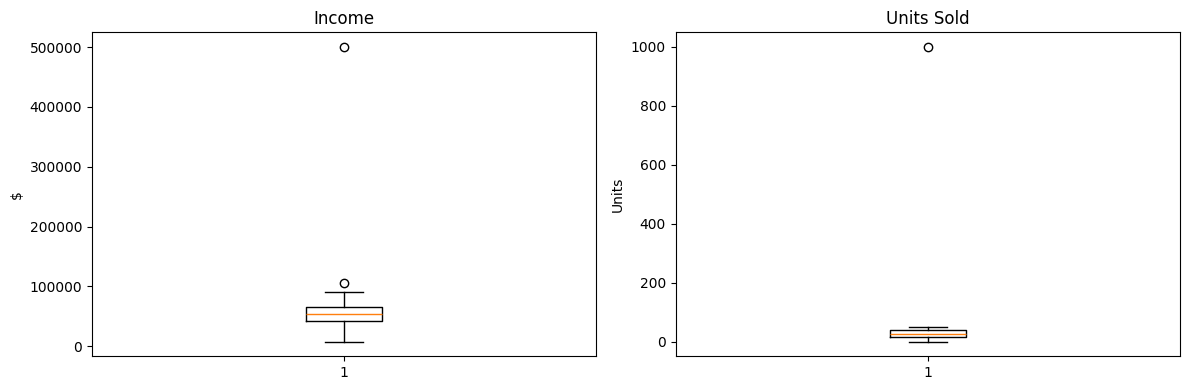

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['income'].dropna());       axes[0].set_title('Income');       axes[0].set_ylabel('$')
axes[1].boxplot(df['units_sold'].dropna());   axes[1].set_title('Units Sold');   axes[1].set_ylabel('Units')
plt.tight_layout(); plt.show()


**[TODO 5]** Create boxplots for **`num_complaints`** and **`years_as_customer`** (same style as the demo above).  
Identify any outlier values and note them in your answers below.


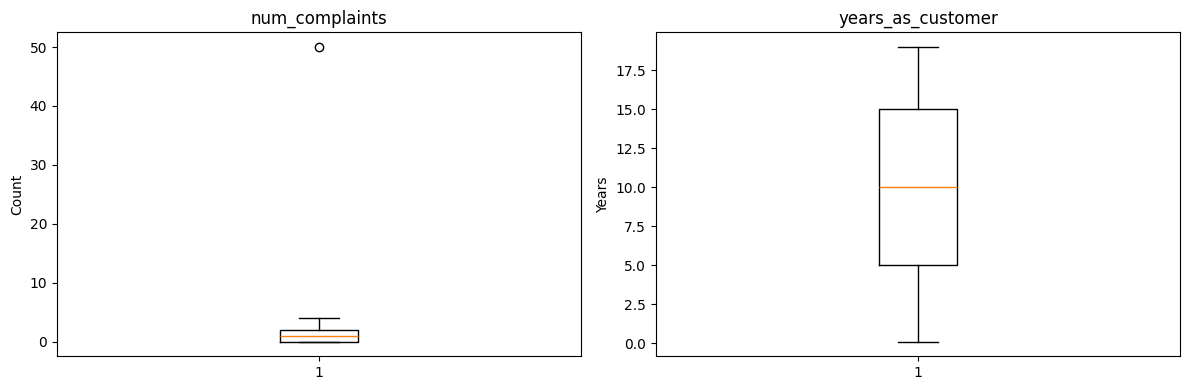

In [ ]:
# TODO 5 ── Boxplots for new columns ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot num_complaints
axes[0].boxplot(df['num_complaints'].dropna());   axes[0].set_title('num_complaints');   axes[0].set_ylabel('Complaints')
axes[0].set_title('num_complaints')
axes[0].set_ylabel('Count')

# Plot years_as_customer
axes[1].boxplot(df['years_as_customer'].dropna());   axes[1].set_title('years_as_customer');   axes[1].set_ylabel('Years')
axes[1].set_title('years_as_customer')
axes[1].set_ylabel('Years')

plt.tight_layout()
plt.show()


**[DEMO]** Bin-mean and bin-boundary smoothing on `price`.

In [ ]:
price_df = df[['price']].dropna().copy().reset_index(drop=True)
price_df['bin'] = pd.cut(price_df['price'], bins=5, labels=False)

price_df['smoothed_mean']     = price_df.groupby('bin')['price'].transform('mean')
bin_min = price_df.groupby('bin')['price'].transform('min')
bin_max = price_df.groupby('bin')['price'].transform('max')
price_df['smoothed_boundary'] = price_df.apply(
    lambda r: bin_min[r.name]
    if abs(r['price'] - bin_min[r.name]) <= abs(r['price'] - bin_max[r.name])
    else bin_max[r.name], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, c in zip(axes,
        ['price','smoothed_mean','smoothed_boundary'],
        ['Original','Bin Mean','Bin Boundary'],
        ['steelblue','darkorange','seagreen']):
    ax.plot(price_df[col].values, alpha=0.7, color=c)
    ax.set_title(title); ax.set_xlabel('Index'); ax.set_ylabel('Price ($)')
plt.tight_layout(); plt.show()


**[TODO 6]** Apply **bin-mean smoothing** to `num_complaints` (use 4 bins).  
Then plot the original vs. smoothed series side-by-side.


In [ ]:
# TODO 6 ── Bin-mean smoothing on num_complaints ─────────────────────────
comp_df = df[['num_complaints']].dropna().copy().reset_index(drop=True)

# Step 1: assign bins (4 equal-width bins)
comp_df['bin'] = pd.cut(comp_df['num_complaints'], bins=___, labels=False)

# Step 2: compute smoothed values using bin mean
comp_df['smoothed'] = comp_df.groupby('bin')['num_complaints'].transform(___)

# Step 3: plot original vs smoothed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(comp_df['num_complaints'].values, color='steelblue', alpha=0.8)
axes[0].set_title('Original: num_complaints')

axes[1].plot(comp_df[___________].values, color='darkorange', alpha=0.8)
axes[1].set_title('Smoothed by Bin Mean')

for ax in axes: ax.set_xlabel('Index'); ax.set_ylabel('Complaints')
plt.tight_layout()
plt.show()


### ✏️ Questions — Step 3

1. Which column had the most extreme outlier from your boxplots? What was the value?
2. After smoothing `num_complaints`, can you still identify the customer with 50 complaints?  
   What does this reveal about a risk of smoothing?
3. Would you smooth `years_as_customer` before feeding it to a model? Why or why not?

> **Write your answers here:**
>
> 1.
> 2.
> 3.


---
## Part 2 — Normalisation & Transformation

We work on a **clean copy**: outlier row removed, all missing values filled.


In [ ]:
# Build clean working copy
df_clean = df_class.copy()
df_clean = df_clean[df_clean['income'] < 200000].reset_index(drop=True)
df_clean = df_clean[df_clean['num_complaints'] < 30].reset_index(drop=True)

print(f"Working dataset: {len(df_clean)} rows")
df_clean[['income','years_as_customer','num_complaints']].describe().round(2)


---
### Step 4 · Three Normalisation Methods (20 min)

We normalise **`income`** in full as a demo, then you repeat the process for the other numeric columns.


**[DEMO]** All three normalisation methods applied to `income`.

In [ ]:
# Min-Max
i_min, i_max = df_clean['income'].min(), df_clean['income'].max()
df_clean['income_minmax']  = (df_clean['income'] - i_min) / (i_max - i_min)

# Z-Score
i_mean, i_std = df_clean['income'].mean(), df_clean['income'].std()
df_clean['income_zscore']  = (df_clean['income'] - i_mean) / i_std

# Decimal Scaling
j = len(str(int(df_clean['income'].abs().max())))
df_clean['income_decimal'] = df_clean['income'] / (10 ** j)

df_clean[['income','income_minmax','income_zscore','income_decimal']].describe().round(3)


**[TODO 7]** Apply **min-max normalisation** to `years_as_customer`.  
Map it to the range [0, 1] using the same formula as the demo.


In [ ]:
# TODO 7 ── Min-Max normalisation for years_as_customer ──────────────────
yc_min = ___________________
yc_max = ___________________

df_clean['years_as_customer_minmax'] = ___________________

print(f"Min: {df_clean['years_as_customer_minmax'].min():.3f}")
print(f"Max: {df_clean['years_as_customer_minmax'].max():.3f}")


**[TODO 8]** Apply **z-score normalisation** to `num_complaints`.  
Print the resulting mean and standard deviation to verify it worked correctly.


In [ ]:
# TODO 8 ── Z-Score normalisation for num_complaints ─────────────────────
c_mean = ___________________
c_std  = ___________________

df_clean['num_complaints_zscore'] = ___________________

print(f"Mean after z-score : {df_clean['num_complaints_zscore'].mean():.3f}  (should be ≈ 0)")
print(f"Std  after z-score : {df_clean['num_complaints_zscore'].std():.3f}   (should be ≈ 1)")


**[DEMO]** Compare all normalised income distributions.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, title, color in zip(
        axes.flat,
        ['income','income_minmax','income_zscore','income_decimal'],
        ['Original Income','Min-Max [0,1]','Z-Score (μ=0,σ=1)','Decimal Scaling'],
        ['steelblue','darkorange','seagreen','mediumpurple']):
    ax.hist(df_clean[col], bins=25, edgecolor='black', color=color, alpha=0.85)
    ax.set_title(title); ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
plt.suptitle('Income — Before and After Normalisation', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


**[TODO 9]** Create a **side-by-side histogram** comparing:
- `years_as_customer` (original) vs. `years_as_customer_minmax`
- `num_complaints` (original) vs. `num_complaints_zscore`

Arrange them in a 2×2 grid (one row per column, two charts per row).


In [ ]:
# TODO 9 ── Visualise normalised new columns ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Row 0: years_as_customer
axes[0, 0].hist(___________________, bins=20, edgecolor='black', color='steelblue')
axes[0, 0].set_title('years_as_customer (original)')

axes[0, 1].hist(___________________, bins=20, edgecolor='black', color='darkorange')
axes[0, 1].set_title('years_as_customer (min-max)')

# Row 1: num_complaints
axes[1, 0].hist(___________________, bins=20, edgecolor='black', color='seagreen')
axes[1, 0].set_title('num_complaints (original)')

axes[1, 1].hist(___________________, bins=20, edgecolor='black', color='mediumpurple')
axes[1, 1].set_title('num_complaints (z-score)')

for ax in axes.flat:
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### ✏️ Questions — Step 4

1. After min-max normalisation of `years_as_customer`, what are the min and max?  
   A new customer joins with 25 years of tenure (beyond the training max). What value would they get?
2. You applied z-score to `num_complaints`. Why might z-score be a better choice than  
   min-max for a skewed, count-based variable?
3. Does normalisation change the **shape** of the distribution? Look at your histograms to decide.

> **Write your answers here:**
>
> 1.
> 2.
> 3.


---
### Step 5 · Discretisation (20 min)

We convert continuous numeric attributes into labelled categories — a concept hierarchy.


**[DEMO]** Equal-width and equal-frequency binning of `income`.

In [ ]:
df_clean['income_band_ew'] = pd.cut(df_clean['income'], bins=3,
                                     labels=['Low','Medium','High'])
df_clean['income_band_ef'] = pd.qcut(df_clean['income'], q=3,
                                      labels=['Low','Medium','High'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = ['Low','Medium','High']
df_clean['income_band_ew'].value_counts().loc[order].plot(
    kind='bar', ax=axes[0], color=['steelblue','darkorange','seagreen'],
    edgecolor='black', title='Income — Equal-Width')
df_clean['income_band_ef'].value_counts().loc[order].plot(
    kind='bar', ax=axes[1], color=['steelblue','darkorange','seagreen'],
    edgecolor='black', title='Income — Equal-Frequency')
for ax in axes: ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


**[TODO 10]** Discretise `years_as_customer` into **4 equal-frequency bins**  
with labels `['New', 'Growing', 'Established', 'Loyal']`.  
Print the bin counts and the bin edges.


In [ ]:
# TODO 10 ── Discretise years_as_customer ────────────────────────────────
df_clean['customer_tenure'] = pd.qcut(
    df_clean['years_as_customer'],
    q=___,
    labels=___________________
)

print("Tenure band counts:")
print(df_clean['customer_tenure'].value_counts().sort_index())
print()
print("Bin edges:")
print(pd.qcut(df_clean['years_as_customer'], q=4).cat.categories.tolist())


**[TODO 11]** Discretise `num_complaints` into **3 equal-width bins**  
with labels `['Low', 'Medium', 'High']`. Then build a **crosstab** of  
`complaint_level` vs `credit_risk`. What pattern do you notice?


In [ ]:
# TODO 11 ── Discretise num_complaints ───────────────────────────────────
df_clean['complaint_level'] = pd.cut(
    df_clean['num_complaints'],
    bins=___,
    labels=___________________
)

# Crosstab: complaint_level vs credit_risk
crosstab = pd.crosstab(___________________, ___________________)
print(crosstab)


**[DEMO]** Distribution of customers across regions.

In [ ]:
region_counts = df_clean['region'].value_counts()
region_counts.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(7, 4),
                   title='Customer Count by Region')
plt.ylabel('Count'); plt.xlabel('Region'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


**[TODO 12]** Build a **crosstab** of `region` vs `credit_risk` and  
compute the **row percentages** (i.e., what % of each region's customers fall into each risk category).  
Which region has the highest proportion of High-risk customers?


In [ ]:
# TODO 12 ── Region × Credit Risk crosstab ───────────────────────────────
ct = pd.crosstab(df_clean['region'], df_clean['credit_risk'])
ct_pct = ct.div(ct.sum(axis=1), axis=0).round(3) * 100   # row percentages

print("Raw counts:")
print(ct)
print()
print("Row percentages (%):")
print(ct_pct)


### ✏️ Questions — Step 5

1. Which binning method produces more **balanced** tenure bands for `years_as_customer`?
2. From the `complaint_level` × `credit_risk` crosstab, is there a visible relationship  
   between number of complaints and credit risk? Describe it.
3. From the region percentage table, which region has the highest share of High-risk customers?  
   What might explain this — and what additional data would you want to investigate?

> **Write your answers here:**
>
> 1.
> 2.
> 3.


---
## 🏁 Wrap-Up & Reflection (15 min)

### Summary Table

| Problem Found | Technique Applied | Key Trade-off |
|---------------|-------------------|---------------|
| Missing `income` | Class-based mean imputation | Assumes group structure is meaningful |
| Missing `num_complaints` | Class-based mean imputation | Inflates low-variance groups |
| Missing `years_as_customer` | Class-based mean imputation | Better than global mean for skewed data |
| Outliers in `income`, `num_complaints` | Boxplot detection → row removal | Risk of losing genuine data |
| Noisy `price` / `num_complaints` | Bin-mean smoothing | Loses fine-grained variation |
| Large `income` range | Min-max normalisation | Sensitive to outliers |
| Skewed `num_complaints` | Z-score normalisation | More robust to outliers than min-max |
| Continuous `income` / `years_as_customer` | Equal-frequency binning | May merge meaningfully different values |

> ✏️ Add rows for any additional techniques you applied.


### Final Reflection Paragraph

Write **one paragraph** answering:

> *"If you were building a model to predict whether a customer is a credit risk (Low / Medium / High),  
> which preprocessing choices from this lab would you make for each column, and why?"*

Consider: imputation strategy, normalisation method, whether to discretise, and how to handle `region`.

> **Write your paragraph here (double-click to edit):**
>
> *(your answer)*


In [ ]:
# 🎉 Final check — all columns and null counts in your cleaned dataset
print("Final dataset shape:", df_clean.shape)
print()
print(f"{'Column':<30} {'dtype':<15} {'nulls':>6}")
print("-" * 55)
for col in df_clean.columns:
    print(f"{col:<30} {str(df_clean[col].dtype):<15} {df_clean[col].isnull().sum():>6}")
